In [2]:
import numpy as np 
import cv2
import matplotlib 
from matplotlib import pyplot as plt 
%matplotlib inline

##### When we look at any image, most of the time we identify a person using a face. An image might contain multiple faces, also the face can be obstructed and not clear. The first step in our pre-processing pipeline is to detect faces from an image. Once face is detected, we will detect eyes, if two eyes are detected then only we keep that image otherwise discard it.

In [ ]:
# Load the image and print its shape using OpenCV imread function

In [3]:
img = cv2.imread("./test_images/abiy1.jpg")
print(img.shape)

(186, 271, 3)


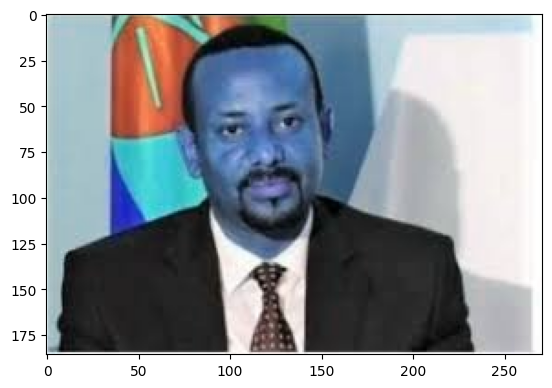

In [4]:
plt.imshow(img) # show the image using matplotlib

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # convert the image to grayscale using OpenCV cvtColor function
print(gray.shape)

(186, 271)


In [6]:
gray # show the array of the grayscale image every 
    # pixel value in the grayscale image is represented as a single intensity value between 0 and 255, 
    # where 0 represents black and 255 represents white.

array([[253, 230, 244, ..., 252, 252, 254],
       [247, 215, 215, ..., 252, 252, 254],
       [252, 213, 205, ..., 252, 252, 254],
       ...,
       [239, 157, 130, ..., 252, 252, 255],
       [228, 178, 147, ..., 254, 255, 255],
       [245, 234, 242, ..., 255, 254, 250]], shape=(186, 271), dtype=uint8)

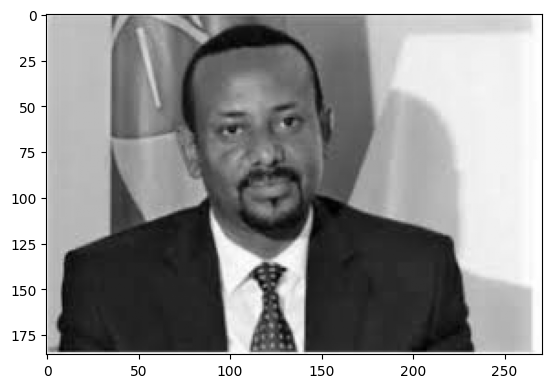

In [7]:
plt.imshow(gray, cmap='gray') # show the grayscale image using matplotlib with a colormap of 'gray'

In [8]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml') # load the Haar Cascade classifier for frontal face detection 
                                               # using OpenCV CascadeClassifier function
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml') # load the Haar Cascade classifier for eye detection 
                                               # using OpenCV CascadeClassifier function
faces = face_cascade.detectMultiScale(gray, 1.3, 5) # detect faces in the grayscale image using OpenCV detectMultiScale function and the numbers indicate the scale factor and minimum neighbors for the detection
faces

array([[78, 28, 84, 84]], dtype=int32)

In [9]:
if len(faces) == 0: # check if any faces were detected
    print("No faces detected.")
else:
    (x,y,w,h) = faces[0] # get the coordinates and dimensions of the first detected face
    x,y,w,h
x,y,w,h # print the coordinates and dimensions of the detected face    

(np.int32(78), np.int32(28), np.int32(84), np.int32(84))

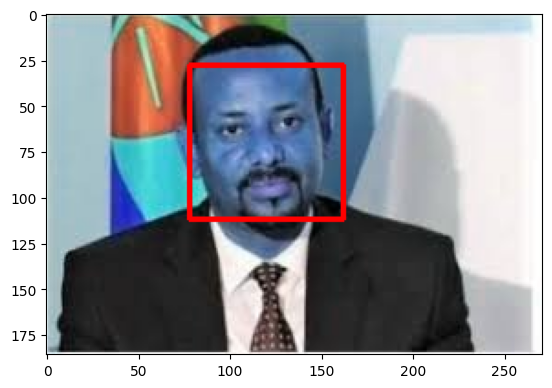

In [10]:
face_image = cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0),2) # draw a rectangle around the detected face using OpenCV rectangle function with the specified coordinates, color, and thickness
plt.imshow(face_image) # show the image with the detected face highlighted using matplotlib 

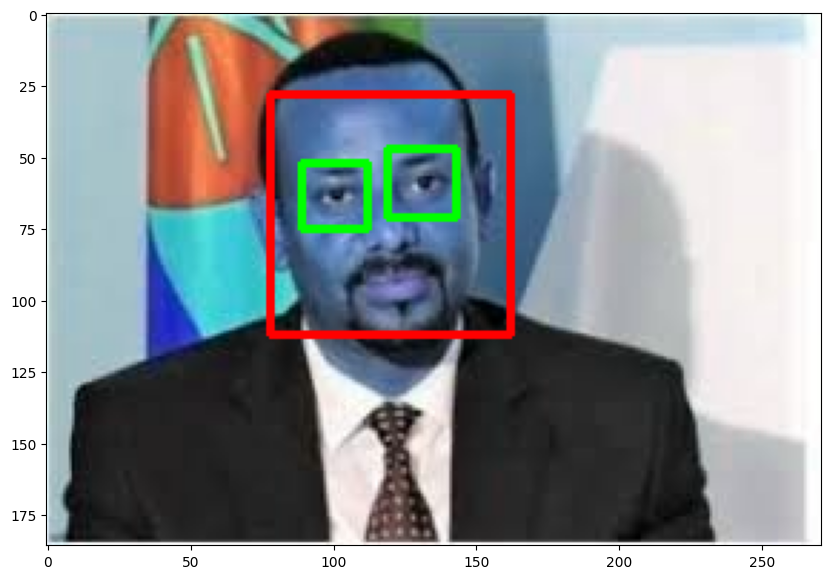

In [13]:
cv2.destroyAllWindows() # close all OpenCV windows
for (x,y,w,h) in faces: # loop through all detected faces and draw rectangles around them
    cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0), 2) # draw a rectangle around each detected face using OpenCV rectangle function with the specified coordinates, color, and thickness
    roi_gray = gray[y:y+h, x:x+w] # extract the region of interest (ROI) for the detected face in the grayscale image
    roi_color = face_image[y:y+h, x:x+w] # extract the region of interest
    eyes = eye_cascade.detectMultiScale(roi_gray) # detect eyes within the ROI of the detected face using OpenCV detectMultiScale function
    for (ex,ey,ew,eh) in eyes: # loop through all detected
        cv2.rectangle(roi_color, (ex,ey), (ex+ew, ey+eh), (0,255,0), 2) # draw a rectangle around each detected eye using OpenCV rectangle function with the specified coordinates, color, and thickness
plt.figure(figsize=(10,10)) # set the figure size for displaying the image
plt.imshow(face_image, cmap = 'gray')  # show the image with detected faces and eyes highlighted using matplotlib
plt.show()

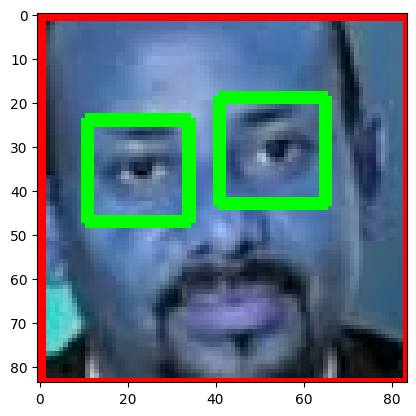

In [15]:
%matplotlib inline
plt.imshow(roi_color, cmap = 'gray')  # show the region of interest (ROI) for the detected face with detected eyes highlighted using matplotlib
plt.show()

In [21]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path) # read the image from the specified path using OpenCV imread function
    if img is None: # check if the image was successfully loaded
        print(f"Skipping unreadable image: {image_path}")
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # convert the image to grayscale using OpenCV cvtColor function
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2: # check if at least two eyes were detected
            return roi_color # return the region of interest (ROI) for the detected face with detected eyes highlighted

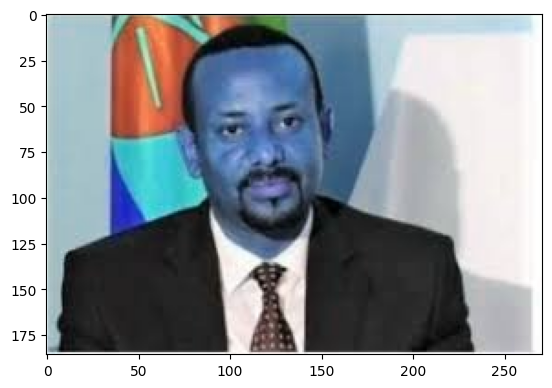

In [17]:
original_img = cv2.imread("./test_images/abiy1.jpg")
plt.imshow(original_img) # show the original image using matplotlib

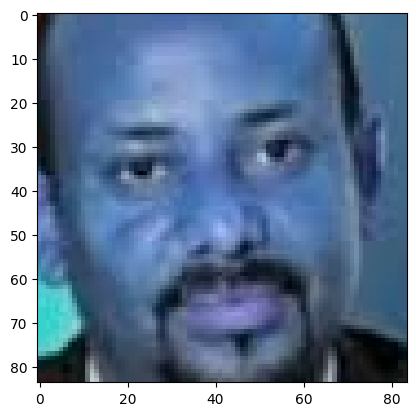

In [22]:
cropped_image = get_cropped_image_if_2_eyes("./test_images/abiy1.jpg")
plt.imshow(cropped_image) # show the cropped image with detected face and eyes using matplotlib

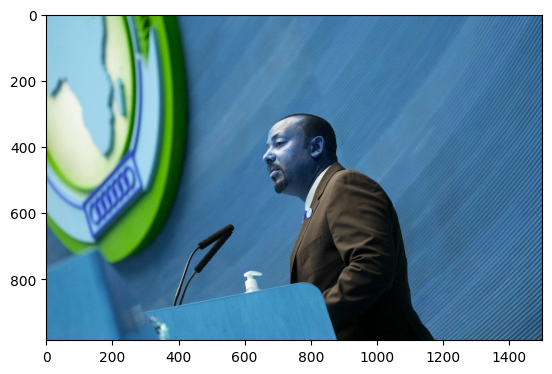

In [23]:
original_img = cv2.imread("./test_images/abiy2.jpg")
plt.imshow(original_img) # show the original image using matplotlib

In [27]:
cropped_image_no_2_eyes = get_cropped_image_if_2_eyes('./test_images/abiy2.jpg')
cropped_image_no_2_eyes

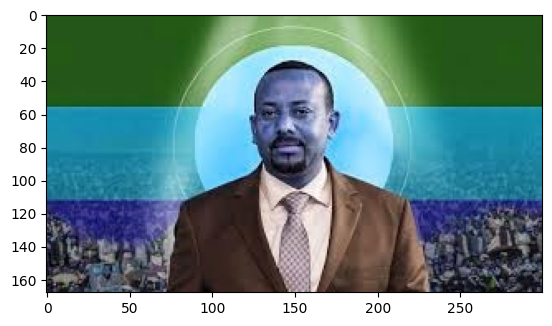

In [28]:
org_image_obstructed = cv2.imread('./test_images/abiy.jpg')
plt.imshow(org_image_obstructed)

In [29]:
cropped_image_no_2_eyes = get_cropped_image_if_2_eyes('./test_images/abiy.jpg')
cropped_image_no_2_eyes # show the cropped image with detected face and eyes using matplotlib, which should return None since the image is obstructed and does not have two detectable eyes

In [32]:
path_to_data = './dataset/'
path_to_cr_data = './dataset/cropped/' # create a new directory for storing the cropped images with detected faces and eyes

In [33]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path) # 

In [34]:
img_dirs # 

['./dataset/Dr. Abiy_Ahmed',
 './dataset/Hailemariam_Desalegn',
 './dataset/Mengistu_Hailemariam',
 './dataset/Emperor_Haileslasie',
 './dataset/Meles_Zenawi']